In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/kc_house_data_processed.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/kc_house_data_processed.csv'

In [3]:
import os

print(os.listdir("../data"))

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../data'

In [4]:
import os
print(os.getcwd())

C:\Users\shrey\OneDrive\Desktop\Project3_RealEstate


In [1]:
import os
print(os.getcwd())

C:\Users\shrey\OneDrive\Desktop\Project3_RealEstate\notebooks


In [4]:
df = pd.read_csv("../data/kc_house_data_processed.csv")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/kc_house_data_processed.csv")

In [6]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [7]:
print(df[['lat', 'long']].head())

       lat     long
0  47.5112 -122.257
1  47.7210 -122.319
2  47.7379 -122.233
3  47.5208 -122.393
4  47.6168 -122.045


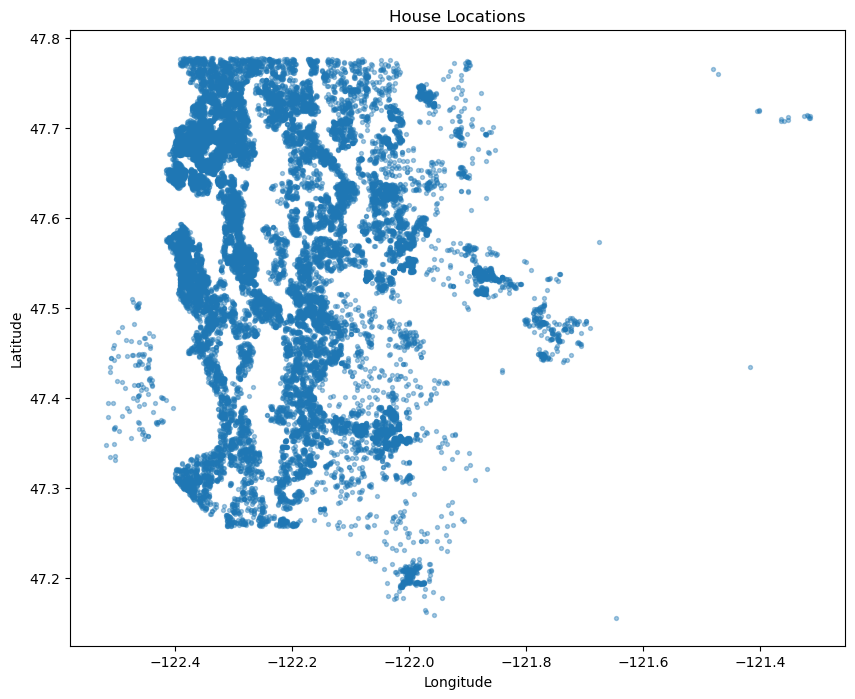

In [8]:
plt.figure(figsize=(10,8))

plt.scatter(
    df['long'],
    df['lat'],
    alpha=0.4,
    s=8
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Locations")

plt.show()

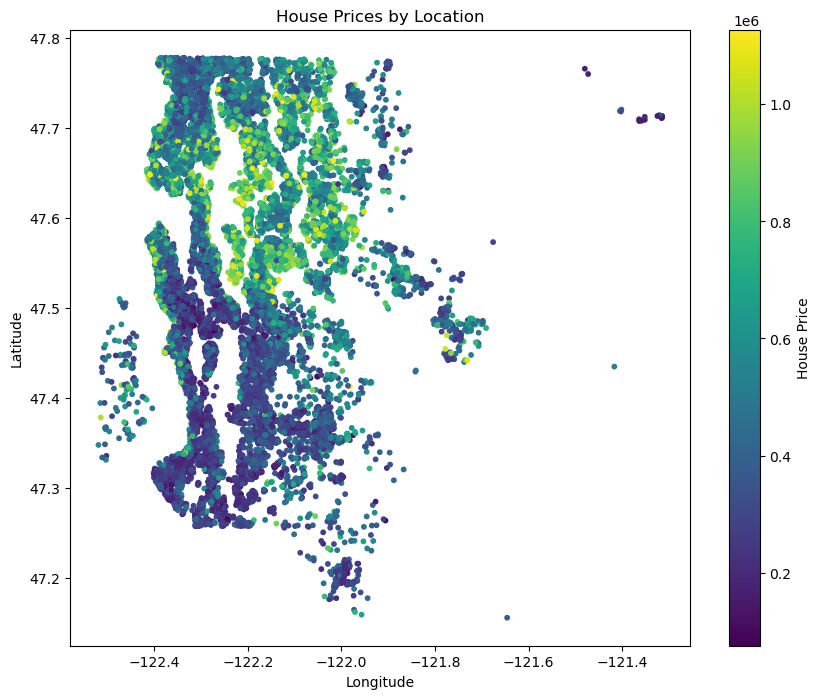

In [9]:
plt.figure(figsize=(10,8))

plt.scatter(
    df['long'],
    df['lat'],
    c=df['price'],
    cmap='viridis',
    s=10
)

plt.colorbar(label="House Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Prices by Location")

plt.show()

In [10]:
df["location_score"] = np.sqrt(df["lat"]**2 + df["long"]**2)

df[["lat", "long", "location_score"]].head()

,lat,long,location_score
0,47.5112,-122.257,131.164356
1,47.7210,-122.319,131.298254
2,47.7379,-122.233,131.224287
3,47.5208,-122.393,131.294603
4,47.6168,-122.045,131.005121


In [11]:
corr = df[["price", "lat", "long", "location_score"]].corr()

print(corr)

                   price       lat      long  location_score
price           1.000000  0.430762  0.070863        0.084917
lat             0.430762  1.000000 -0.132916        0.463266
long            0.070863 -0.132916  1.000000       -0.939932
location_score  0.084917  0.463266 -0.939932        1.000000


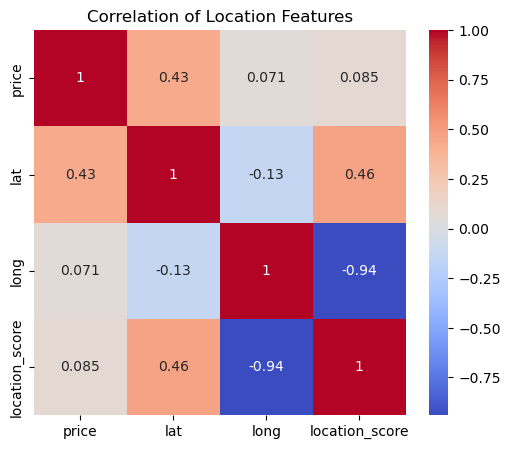

In [12]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation of Location Features")

plt.show()

In [13]:
df.to_csv("../data/kc_house_data_spatial.csv", index=False)

print("Spatial dataset saved successfully!")

Spatial dataset saved successfully!
